## Load Dataset 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('loan_data.csv')

In [3]:
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Number of rows:  614
Number of columns:  13


In [6]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [7]:
for column in df.columns:
    print(column)

Loan_ID
Gender
Married
Dependents
Education
Self_Employed
ApplicantIncome
CoapplicantIncome
LoanAmount
Loan_Amount_Term
Credit_History
Property_Area
Loan_Status


In [8]:
df.info

<bound method DataFrame.info of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849          

In [9]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [10]:
# count of each data type in the dataframe
df.dtypes.value_counts()

object     8
float64    4
int64      1
Name: count, dtype: int64

In [11]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [12]:
df["Loan_Status"].head()

0    Y
1    N
2    Y
3    Y
4    Y
Name: Loan_Status, dtype: object

In [13]:
df["Education"].head(10)

0        Graduate
1        Graduate
2        Graduate
3    Not Graduate
4        Graduate
5        Graduate
6    Not Graduate
7        Graduate
8        Graduate
9        Graduate
Name: Education, dtype: object

In [14]:
categorical_columns = df.select_dtypes(include=['object']).columns
for column in categorical_columns:
    print(f"\n{column}")
    print(f"{column}:{df[column].nunique()} unique values")
    # print(df[column].unique())



Loan_ID
Loan_ID:614 unique values

Gender
Gender:2 unique values

Married
Married:2 unique values

Dependents
Dependents:4 unique values

Education
Education:2 unique values

Self_Employed
Self_Employed:2 unique values

Property_Area
Property_Area:3 unique values

Loan_Status
Loan_Status:2 unique values


In [15]:
# missing values in the dataset
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [16]:
# missing value percentage in the dataset
missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage.sort_values(ascending=False)

Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Education            0.000000
Loan_ID              0.000000
CoapplicantIncome    0.000000
ApplicantIncome      0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [17]:
# duplicates rows in the dataset
duplicate_rows = df[df.duplicated()]
duplicate_rows
df.duplicated().sum()

np.int64(0)

In [18]:
df["Loan_ID"].duplicated().sum()

np.int64(0)

In [19]:
# statical summary of the dataset
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [20]:
# categorical summary  in the dataset
df.describe(include=['object'])

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [21]:
# target variable identify
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [22]:
X = df.drop("Loan_Status", axis=1)
Y = df["Loan_Status"]

In [23]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical columns: ", numerical_columns)
print(list(numerical_columns))
print("Categorical columns: ", categorical_columns)
print(list(categorical_columns))

Numerical columns:  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical columns:  Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [24]:
# business question -> data analysis -> Visualization -> observations -> Business insights 

In [25]:
# Does credit history affect the loan approval?
# credit_history -> 1.0 -> credit history is positive, 0.0 -> credit history is negative/not indentified
# loan_status -> Y -> loan approved, N -> loan not approved
pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index') * 100



Loan_Status,N,Y
Credit_History,,
0.0,92.134831,7.865169
1.0,20.421053,79.578947


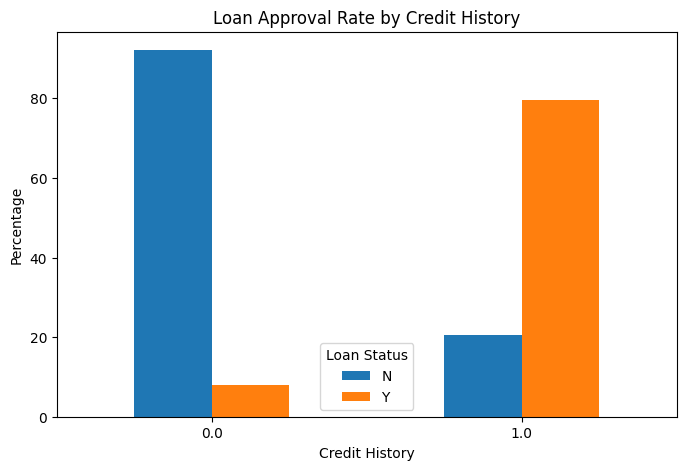

In [26]:
# visualization of the relationship between credit history and loan approval
credit_approval = pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index') * 100
credit_approval.plot(kind='bar', figsize=(8, 5))
plt.title('Loan Approval Rate by Credit History')
plt.xlabel('Credit History')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')
plt.show()

In [27]:
# Does applicant income affect the loan approval? 
# Do approved applicants actually have different income distribution compared with rejected applicants?
df.groupby('Loan_Status')['ApplicantIncome'].agg(['mean', 'median', 'std', 'min', 'max'])

,mean,median,std,min,max
Loan_Status,,,,,
N,5446.078125,3833.5,6819.558528,150,81000
Y,5384.068720,3812.5,5765.441615,210,63337


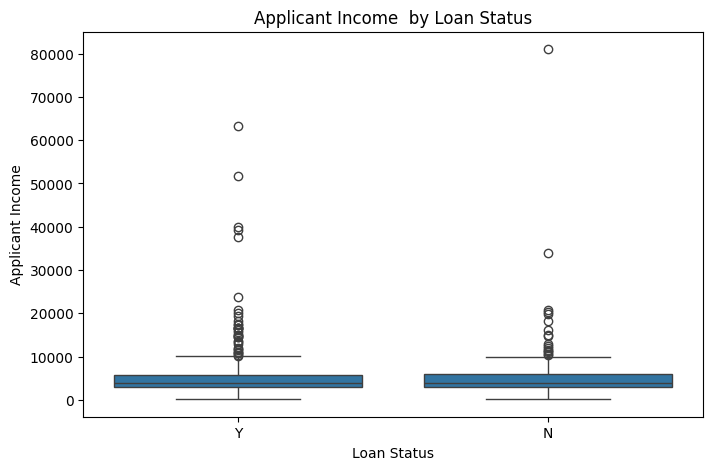

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Applicant Income  by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.show()


In [29]:
# Does loan amount affect the loan approval?
df.groupby('Loan_Status')['LoanAmount'].describe()
df.groupby('Loan_Status')['LoanAmount'].agg(['mean', 'median', 'std', 'min', 'max'])

,mean,median,std,min,max
Loan_Status,,,,,
N,151.220994,129.0,85.862783,9.0,570.0
Y,144.294404,126.0,85.484607,17.0,700.0


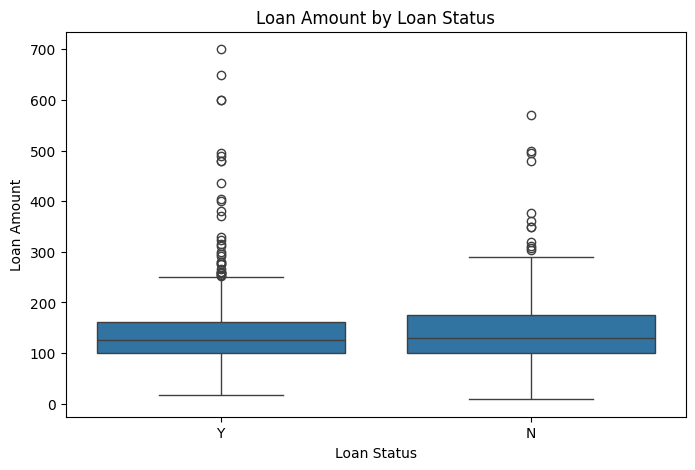

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.title('Loan Amount by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.show()

In [31]:
# does education affect the loan approval?
education_approval = pd.crosstab(df['Education'], df['Loan_Status'], normalize='index') * 100
education_approval

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


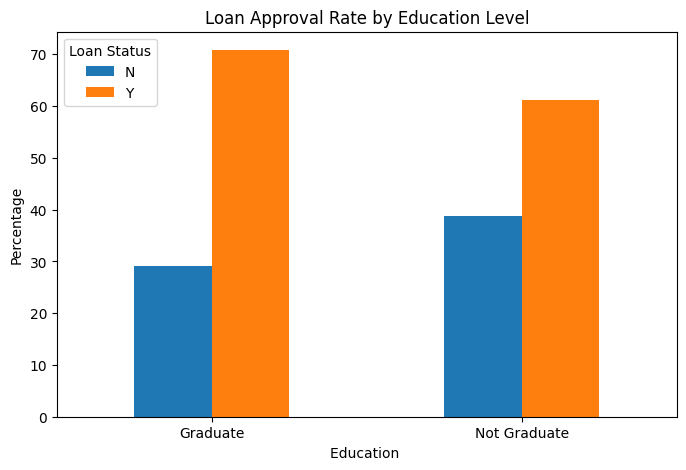

In [32]:
education_approval.plot(kind='bar', figsize=(8, 5))
plt.title('Loan Approval Rate by Education Level')
plt.xlabel('Education ')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')
plt.show()


In [33]:
# does property area affect the loan approval?
property_approval = pd.crosstab(df['Property_Area'], df['Loan_Status'], normalize='index') * 100    
property_approval

Loan_Status,N,Y
Property_Area,,
Rural,38.547486,61.452514
Semiurban,23.175966,76.824034
Urban,34.158416,65.841584


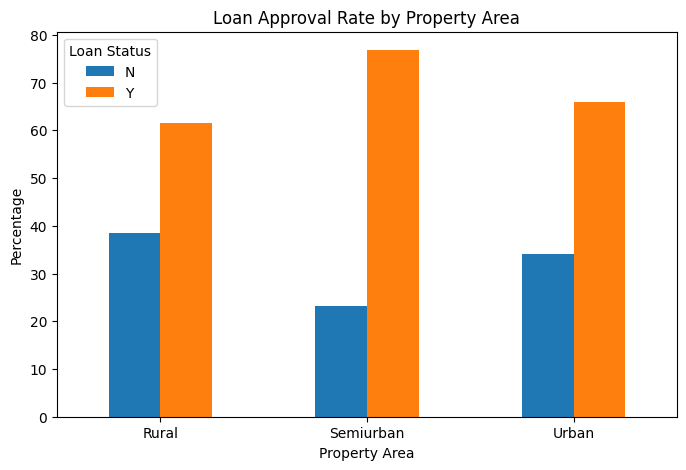

In [34]:
property_approval.plot(kind='bar', figsize=(8, 5))
plt.title('Loan Approval Rate by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')
plt.show()

In [35]:
# identify target and unnecessary columns
X =df.drop(columns=['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

In [36]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [37]:
# missing value imputation
X_train.isnull().sum()

Gender               11
Married               3
Dependents            8
Education             0
Self_Employed        27
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           20
Loan_Amount_Term     12
Credit_History       43
Property_Area         0
dtype: int64

In [38]:
X_train.shape

(491, 11)

In [39]:
# Numerical and categorical columns
numerical_features =['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area','Credit_History']

In [40]:
X_train[numerical_features].isnull().sum()

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           20
Loan_Amount_Term     12
dtype: int64

In [41]:
# categorical columns missing value imputation
X_train[categorical_features].isnull().sum()

Gender            11
Married            3
Dependents         8
Education          0
Self_Employed     27
Property_Area      0
Credit_History    43
dtype: int64

In [42]:
# encoding categorical variables
# one-hot encoding for categorical variables
#property area => urban, semiurban, rural 

In [43]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
encoded =encoder.fit_transform(X_train[["Property_Area"]])

In [44]:
encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(["Property_Area"]))
encoded_df.head()

,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,1.0,0.0


In [45]:
categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area','Credit_History']

In [46]:
encoder = OneHotEncoder(handle_unknown='ignore')
encoded = encoder.fit_transform(X_train[categorical_features])

In [47]:
# sacling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_income = scaler.fit_transform(X_train[["LoanAmount"]])
scaled_income[:5]

array([[-1.11845409],
       [-0.58974276],
       [ 0.03091836],
       [-0.39434945],
       [ 0.03091836]])

In [48]:
# IQR :- se outlier 
#Q1:- 25thy percentile
#Q3:- 75th percentile
# IQR = Q3 - Q1

#outlier boundries
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR




In [49]:
# manual preprocessing steps
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_imputer = SimpleImputer(strategy='median')
new_scaler = StandardScaler()

X_train_num = num_imputer.fit_transform(X_train[numerical_features])
X_train_num = new_scaler.fit_transform(X_train_num)


In [50]:
#categorical features preprocessing
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_encoder = OneHotEncoder(handle_unknown='ignore')
X_train_cat = cat_imputer.fit_transform(X_train[categorical_features])
X_train_cat = cat_encoder.fit_transform(X_train_cat)

In [51]:
# pipeline 
from sklearn.pipeline import Pipeline

# numerical pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
# categorical pipeline main pahale missing value imputation and then encoding karte hai.



In [52]:
# column transformer

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [53]:
# final preprocessing 
X_train_preprocessed = preprocessor.fit_transform(X_train)


In [54]:
X_test_preprocessed = preprocessor.transform(X_test)

In [55]:
# feature engineering 

# Feature Engineering 

In [56]:
# applicantincome and coapplicantincome 
df["TotalIncome"]= (df["ApplicantIncome"] +df["CoapplicantIncome"])

In [57]:
# income log transformation
df["TotalIncome"].describe()

count      614.000000
mean      7024.705081
std       6458.663872
min       1442.000000
25%       4166.000000
50%       5416.500000
75%       7521.750000
max      81000.000000
Name: TotalIncome, dtype: float64

In [58]:
# histogram distribution and KDE (Kernel Density Estimation)

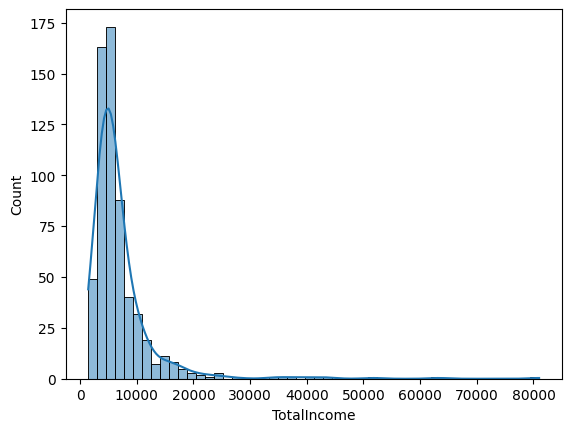

In [59]:
sns.histplot(df["TotalIncome"],kde=True)
plt.show()
# Right skewed Distribution 

In [60]:
# log transformation 
df["TotalIncome_Log"] =np.log1p(df["TotalIncome"])

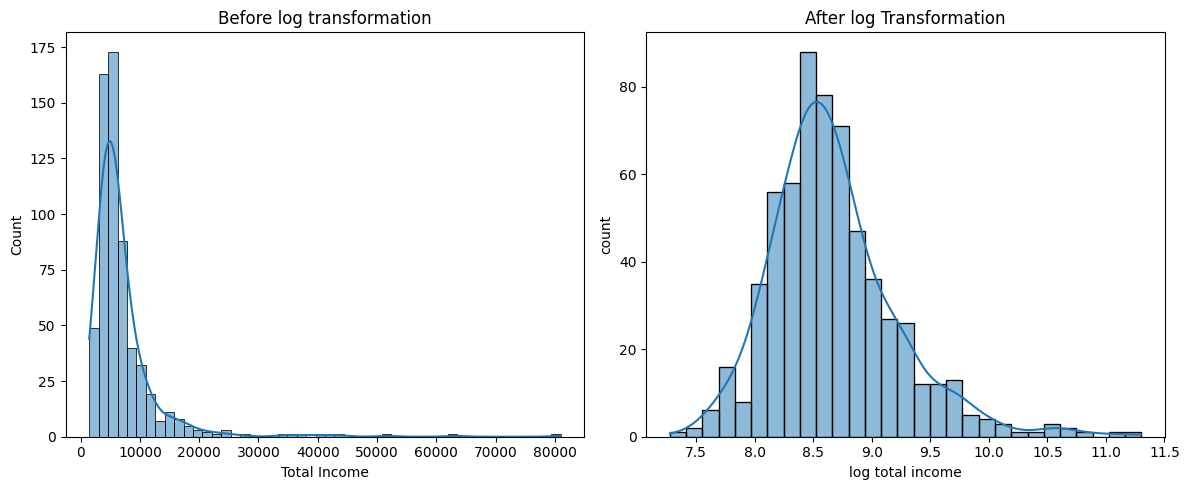

In [61]:
# before and after
#before 
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["TotalIncome"],kde=True)
plt.title("Before log transformation")
plt.xlabel("Total Income")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.histplot(df["TotalIncome_Log"],kde=True)
plt.title("After log Transformation")
plt.xlabel("log total income")
plt.ylabel("count")
plt.tight_layout()
plt.show()


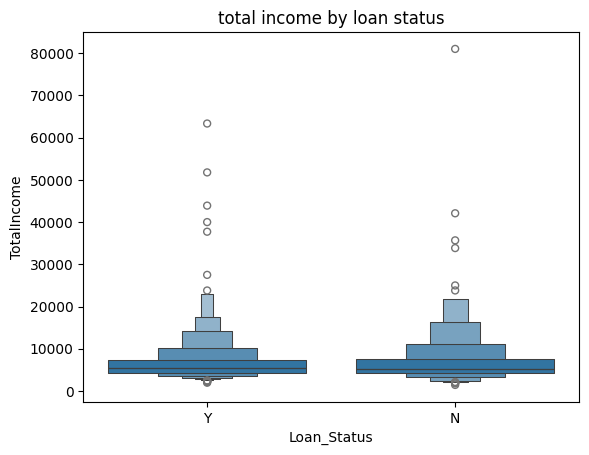

In [62]:
# total income and loanstatus 
sns.boxenplot(
    x = "Loan_Status",
    y = "TotalIncome",
    data=df
)
plt.title("total income by loan status")
plt.show()

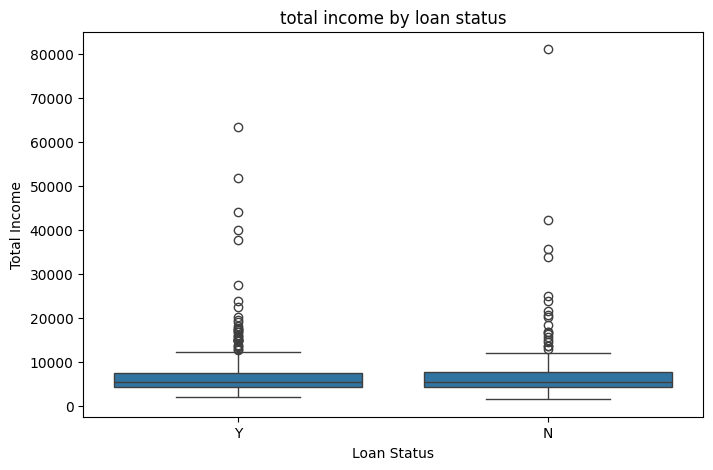

In [63]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x = "Loan_Status",
    y = "TotalIncome",
    data=df
)
plt.title("total income by loan status")
plt.xlabel("Loan Status")
plt.ylabel("Total Income")
plt.show()

# Model Preparation 

In [64]:
# loan approval prediction
# target variable is loan status 
# y -> approved
# N -> Rejected
# logistic Regression 
# house prise -> 50lakh, 70lakh linear regression 
# logistic regression -> probability calculate karta hai
# 0.82 -> 82% 
# if probability is high -> Y
# if Probabiblity is low -> N

In [65]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban


In [66]:
y.head()

0    Y
1    N
2    Y
3    Y
4    Y
Name: Loan_Status, dtype: object

In [67]:
# logistic Regression
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)


In [68]:
# preprocessing + model -> pipeline me combine karenge 

In [69]:
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([("preprocessor",preprocessor),("model",LogisticRegression(max_iter=1000))])

In [70]:
#model traning
logistic_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
# prediction 
y_pred =logistic_pipeline.predict(X_test)

In [72]:
y_pred[:15]

array(['N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N'], dtype=object)

In [73]:
# actual vs predicted 
camparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted":y_pred
})
camparison.head()

,Actual,Predicted
150,N,N
559,Y,Y
598,Y,Y
235,Y,Y
145,Y,Y


In [74]:
# model evaluation
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.8617886178861789


In [75]:
# confusion martix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
print(cm)

[[22 16]
 [ 1 84]]


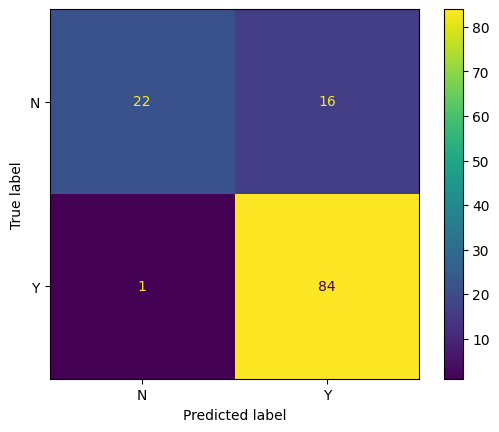

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


In [77]:
# TN :- 22
# FP :- 16
# FN :- 1
# TP :- 84

# | Actual | Predicted | Meaning             | Result         |
# | ------ | --------- | ------------------- | -------------- |
# | N      | N         | Rejected → Rejected | True Negative  |
# | N      | Y         | Rejected → Approved | False Positive |
# | Y      | N         | Approved → Rejected | False Negative |
# | Y      | Y         | Approved → Approved | True Positive  |

# 84 cases mein bank ne actually loan approve kiya aur model ne bhi correctly approve predict kiya.

# 22 cases mein loan actually reject hua aur model ne bhi correctly reject predict kiya.

# Lekin 16 cases mein loan actually reject hua tha, but model ne approve predict kar diya.

# Aur 1 case mein loan actually approve hua tha, but model ne reject predict kar diya.




In [78]:
# Ab ek important business question hai — model ne jitne applicants ko loan approved predict kiya, 
# unmein se actually kitne applicants ka loan approve hua?

In [79]:
# Precision = TP / (TP + FP)
#           = 84 /100
#           = 0.84
#           = 84% 
# model ne jitne applicants ko positive class, yani approved predict kiya, umein se accually kitne approved the ..

In [80]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred, pos_label="Y")
print("Precision:", precision)


Precision: 0.84


In [81]:
print(f"Precision: {precision *100:.2f} %")

Precision: 84.00 %


In [82]:
# accuracy :- model ne total prediction me se kitni prediction correct ki 
# correct = tp +tn  
# Precision :- model ne jitne positive predict kiye , unmein se kitne acctually positive the 
# precision = TP / (TP + FP)
# accuracy :- overall kitna correct ?
# precision ;- Predicted positive me kitna correct ?

In [83]:
# recall 
# Ab Precision ke baad ek aur important question hai — actually jitne applicants ka loan approve hua tha,
# unmein se model ne kitne applicants ko correctly identify kiya :- recall

In [84]:
1 + 84 # actuall approved appilicants 
# 84 correctly predict kiya - TP
# 1 model ne incorrect predict kiya - FP
# Recall = TP /(TP + FN)
#       = 84 /85
#       = 0.98
#       = 98.82%

85

In [85]:
from sklearn.metrics import recall_score

recall  = recall_score(y_test, y_pred, pos_label="Y")
print("Recall:", recall)

Recall: 0.9882352941176471


In [86]:
print(f"Recall: {recall *100:.2f} %")

Recall: 98.82 %


In [87]:
# F1 Score 
# f1 Score :- F1 score precision aur recall dono ko combine karke single score deta hai

In [88]:
# f1 = 2 *(precision* recall)/(precision* recall)

In [89]:
# f1 = 2 * (0.84 * 0.9882) / (0.84 * 0.9882) 
# f1 = 0.9066 -> 90.66%

In [90]:
from sklearn.metrics import f1_score

f1  = f1_score(y_test, y_pred, pos_label="Y")
print("F1 Score :", f1)

F1 Score : 0.9081081081081082


In [91]:
print(f"ReF1 Score: {f1 *100:.2f} %")

ReF1 Score: 90.81 %


In [92]:
# ROC-AUC
# ROC - Receiver operating characteristic 
# example :
# applicant a = 0.90
# applicant b = 0.75
# applicant c = 0.55
# applicant d = 0.35

# probability >= 0.50 Y
# probability < 0.50 N

In [93]:
# ROC curve kya usame plot hota hai ?
# y-axis - true positive rate 
# tpr = tp /(tp + fn)
# x-axis -> False positive rate
# fpr = FP / (Fp + TN)

TP = 80
FN = 20
FP = 10
TN = 90

# tpr = 80 / 100 = 80%
# fpr = 10 /100 = 10%

# # applicant a = 0.90
# # applicant b = 0.75
# # applicant c = 0.55
# # applicant d = 0.35

# # Roc curve 
# Threshold    TPR       FPR
# --------------------------------
# 0.90         40%       2%
# 0.70         65%       5%
# 0.50         80%       10%
# 0.30         92%       25%
# 0.10         98%       60%


In [94]:
 # AUC - Area under the curve
 #|     AUC | Meaning                        |
# | ------: | ------------------------------ |
# |     1.0 | Excellent / perfect separation |
# |    0.9+ | Very good                      |
# | 0.8–0.9 | Good                           |
# | 0.7–0.8 | Acceptable                     |
# |     0.5 | Random guessing                |
# |   < 0.5 | Worse than random              |

# ROc curve 
# TPR
# 1.0 |                         ______
#     |                    ____/
#     |                ___/
#     |             __/
#     |          __/
#     |       __/
#     |    __/
# 0.0 |___/____________________________
#      0.0                            1.0
#                  FPR




In [95]:
y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]


In [96]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test,y_prob)
print("ROC-AUC:",roc_auc)

ROC-AUC: 0.8526315789473684


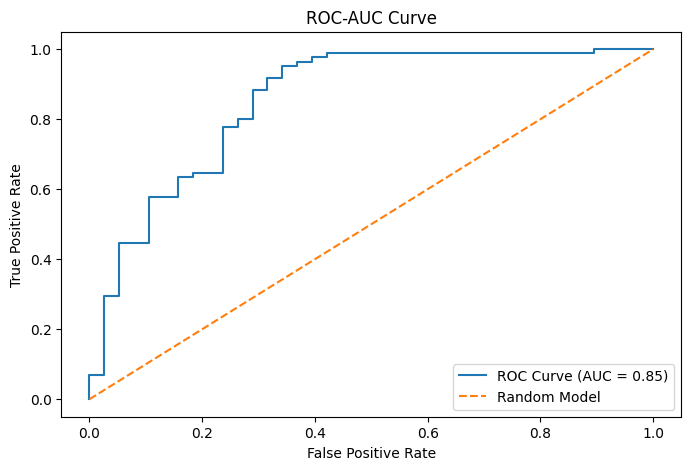

In [97]:
# roc curve visualization 
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label="Y")

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()

plt.show()

In [98]:
# k-Nearest Neighbors(KNN)
from sklearn.neighbors import KNeighborsClassifier
knn_pipeline = Pipeline([("preprocessor", preprocessor), ("model", KNeighborsClassifier(n_neighbors=5))])

In [99]:
knn_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [100]:
y_pred_knn = knn_pipeline.predict(X_test)

# test applicant -> preprocessing -> distance calculate -> 3 nearest neighbors -> majority voting -> predict loan status

In [101]:
print("KNN Predictions:", y_pred_knn[:15])

KNN Predictions: ['N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N']


In [102]:
# accuracy 
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.8292682926829268


In [103]:
# precision 
from sklearn.metrics import precision_score

precision_knn = precision_score(y_test, y_pred_knn, pos_label="Y")
print("KNN Precision:", precision_knn)

KNN Precision: 0.8137254901960784


In [104]:
# recall 
from sklearn.metrics import recall_score

recall_knn = recall_score(y_test, y_pred_knn, pos_label="Y")
print("KNN Recall:", recall_knn)

KNN Recall: 0.9764705882352941


In [105]:
# f1 score 
from sklearn.metrics import f1_score

f1_knn = f1_score(y_test, y_pred_knn, pos_label="Y")
print("KNN F1 Score:", f1_knn)

KNN F1 Score: 0.8877005347593583


In [106]:
y_pred_knn = knn_pipeline.predict(X_test)

In [107]:
from sklearn.metrics import roc_auc_score

roc_auc_knn = roc_auc_score(y_test, knn_pipeline.predict_proba(X_test)[:, 1])
print("KNN ROC AUC:", roc_auc_knn)

KNN ROC AUC: 0.8072755417956656


In [108]:
# comparison of logistic regression and KNN model performance

camparison_df =pd.DataFrame({
    "Metrics":[
        "accuracy",
        "precision",
        "Recall",
        "f1 Score",
        "ROC AUC"
    ],
    "Logistic Regression":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "KNN":[
        accuracy_knn,
        precision_knn,
        recall_knn,
        f1_knn,
        roc_auc_knn
    ]
})

camparison_df

,Metrics,Logistic Regression,KNN
0,accuracy,0.861789,0.829268
1,precision,0.840000,0.813725
2,Recall,0.988235,0.976471
3,f1 Score,0.908108,0.887701
4,ROC AUC,0.852632,0.807276


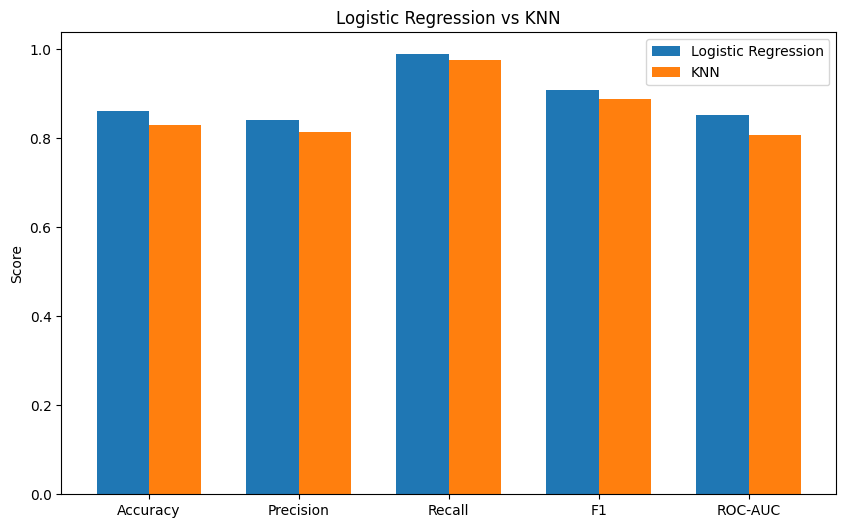

In [109]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

logistic_scores = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

knn_scores = [
    accuracy_knn,
    precision_knn,
    recall_knn,
    f1_knn,
    roc_auc_knn
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    logistic_scores,
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    knn_scores,
    width,
    label="KNN"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Logistic Regression vs KNN")
plt.legend()

plt.show()

In [110]:
# decision tree classifier
# for entropy based 
# calculate entropy -> calculated weighted child entropy -> calculate  information gain -> compare condidate splits -> HIgher information gain -> better split
# gini use kar rahe hai to 
# parent gini -> child gini -> weighted child gini -> impurity reduction -> best split 


In [111]:
# decision tree classifier
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42))
])


In [112]:
decision_tree_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [113]:
y_pred_dt = decision_tree_pipeline.predict(X_test)

In [114]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt, labels=["N", "Y"])
print("Decision Tree Confusion Matrix:\n", cm_dt)


Decision Tree Confusion Matrix:
 [[21 17]
 [ 5 80]]


In [115]:
# TN :- 21
# FP :- 17
# FN :- 5
# TP :- 80

# | Actual | Predicted | Meaning             | Result         |
# | ------ | --------- | ------------------- | -------------- |
# | N      | N         | Rejected → Rejected | True Negative  |
# | N      | Y         | Rejected → Approved | False Positive |
# | Y      | N         | Approved → Rejected | False Negative |
# | Y      | Y         | Approved → Approved | True Positive  |

In [116]:
# accuracy
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)
# accuracy = (TP + TN) / (TP + TN + FP + FN)

Decision Tree Accuracy: 0.8211382113821138


In [117]:
# precision 
from sklearn.metrics import precision_score
precision_dt = precision_score(y_test, y_pred_dt, pos_label="Y")
print("Decision Tree Precision:", precision_dt)
# precision = TP / (TP + FP)
# model ne jitne applicant ko approved predict kiya hai unme se actually approved kitne the ?

Decision Tree Precision: 0.8247422680412371


In [118]:
# recall
from sklearn.metrics import recall_score

recall_dt = recall_score(y_test, y_pred_dt, pos_label="Y")
print("Decision Tree Recall:", recall_dt)
# actually jitne applicants ka loan approve hua tha, unmein se model ne kitne applicants ko correctly identify kiya :- recall
#recall = TP / (TP + FN)


Decision Tree Recall: 0.9411764705882353


In [119]:
# f1 score
from sklearn.metrics import f1_score
f1_dt = f1_score(y_test, y_pred_dt, pos_label="Y")
print("Decision Tree F1 Score:", f1_dt)
# f1 score = 2 * (precision * recall) / (precision + recall)
# precision aur recall dono ko combine karke single score deta hai.

Decision Tree F1 Score: 0.8791208791208791


In [120]:
# roc-auc
positive_index = list(decision_tree_pipeline.classes_).index("Y")
y_prob_dt = decision_tree_pipeline.predict_proba(X_test)[:, positive_index]

In [121]:
from sklearn.metrics import roc_auc_score
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
print("Decision Tree ROC AUC:", roc_auc_dt)
# roc-auc model ki ability ko measure karta hai ki model approved aur rejected applicants ko kitna effectively separate kar raha hai.


Decision Tree ROC AUC: 0.7258513931888545


In [122]:
# comparison of logistic regression and KNN model performance and decision tree classifier
results_df = pd.DataFrame({
    "Model":
    [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy":[

        accuracy,
        accuracy_knn,
        accuracy_dt
    ],
    "Precision":[
        precision,
        precision_knn,
        precision_dt
    ],
    "Recall":[
        recall,
        recall_knn,
        recall_dt
    ],
    "F1 Score":[
        f1,
        f1_knn,
        f1_dt
    ],
    "ROC AUC":[
        roc_auc,
        roc_auc_knn,
        roc_auc_dt
    ]
})

results_df   

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108,0.852632
1,KNN,0.829268,0.813725,0.976471,0.887701,0.807276
2,Decision Tree,0.821138,0.824742,0.941176,0.879121,0.725851


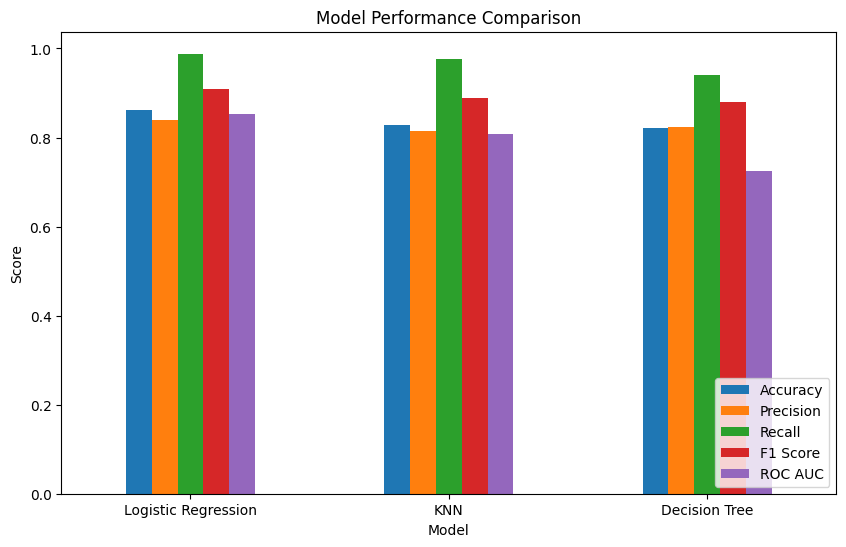

In [123]:
results_df.plot(x="Model", kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [124]:
# random forest classifier

In [127]:
from sklearn.ensemble import RandomForestClassifier
# pipeline
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ))
])

In [128]:
# train the random forest model
random_forest_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [129]:
# prediction
y_pred_rf = random_forest_pipeline.predict(X_test)

In [130]:
# same evaluation metrics for random forest classifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label="Y")
recall_rf = recall_score(y_test, y_pred_rf, pos_label="Y")
f1_rf = f1_score(y_test, y_pred_rf, pos_label="Y")

In [131]:
# roc-auc
positive_index_rf = list(random_forest_pipeline.classes_).index("Y")
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, positive_index_rf]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)


In [132]:
print("Random Forest Classifier Performance:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)
print("ROC AUC:", roc_auc_rf)

Random Forest Classifier Performance:
Accuracy: 0.8536585365853658
Precision: 0.8316831683168316
Recall: 0.9882352941176471
F1 Score: 0.9032258064516129
ROC AUC: 0.8213622291021672


In [133]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy, accuracy_knn, accuracy_dt, accuracy_rf],
    "Precision": [precision, precision_knn, precision_dt, precision_rf],
    "Recall": [recall, recall_knn, recall_dt, recall_rf],
    "F1 Score": [f1, f1_knn, f1_dt, f1_rf],
    "ROC AUC": [roc_auc, roc_auc_knn, roc_auc_dt, roc_auc_rf]
})
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.861789   0.840000  0.988235  0.908108  0.852632
1                  KNN  0.829268   0.813725  0.976471  0.887701  0.807276
2        Decision Tree  0.821138   0.824742  0.941176  0.879121  0.725851
3        Random Forest  0.853659   0.831683  0.988235  0.903226  0.821362


In [134]:
# svm (Support Vector Machine)

In [146]:
# Y - Approved
# N - Rejected
# gender
# married 
# dependents.......

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#create svm model
svm_model = SVC(kernel='rbf', C=1.0)

# create Pipeline for preprocessing and model training
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", svm_model)
])

# Train the SVM model
svm_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_pipeline.predict(X_test)

# calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
# calculate precision
precision_svm = precision_score(y_test, y_pred_svm, pos_label="Y")
# calculate recall
recall_svm = recall_score(y_test, y_pred_svm, pos_label="Y")
# calculate f1 score
f1_svm = f1_score(y_test, y_pred_svm, pos_label="Y")
# calculate roc-auc
positive_index_svm = list(svm_pipeline.classes_).index("Y")
y_score_svm = svm_pipeline.decision_function(X_test)

# Ensure higher scores represent class "Y"
if positive_index_svm == 0:
    y_score_svm = -y_score_svm

roc_auc_svm = roc_auc_score(y_test, y_score_svm)

print("SVM Model Performance:")
print(f"Accuracy: {accuracy_svm}")
print(f"Precision: {precision_svm}")
print(f"Recall: {recall_svm}")
print(f"F1 Score: {f1_svm}")
print(f"ROC-AUC: {roc_auc_svm}")

# accuracy score :- overall kitna correct prediction kiya
# precision score :- model ne jitne positive predict kiye unmein se actually kitne positive the
# recall score :- actually jitne positive the unmein se model ne kitne correctly identify ki
# f1 score :- harmonic mean of precision and recall
# roc-auc score :- model ki ability ko measure karta hai ki model approved aur rejected applicants ko kitna effectively separate kar raha hai.


SVM Model Performance:
Accuracy: 0.8455284552845529
Precision: 0.8235294117647058
Recall: 0.9882352941176471
F1 Score: 0.8983957219251337
ROC-AUC: 0.8182662538699691


In [149]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [accuracy, accuracy_knn, accuracy_dt, accuracy_rf, accuracy_svm],
    "Precision": [precision, precision_knn, precision_dt, precision_rf, precision_svm],
    "Recall": [recall, recall_knn, recall_dt, recall_rf, recall_svm],
    "F1 Score": [f1, f1_knn, f1_dt, f1_rf, f1_svm],
    "ROC AUC": [roc_auc, roc_auc_knn, roc_auc_dt, roc_auc_rf, roc_auc_svm]
})
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.861789   0.840000  0.988235  0.908108  0.852632
1                  KNN  0.829268   0.813725  0.976471  0.887701  0.807276
2        Decision Tree  0.821138   0.824742  0.941176  0.879121  0.725851
3        Random Forest  0.853659   0.831683  0.988235  0.903226  0.821362
4                  SVM  0.845528   0.823529  0.988235  0.898396  0.818266
